In [293]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [294]:
%run src/common_functions.py

# Logistic Regression

Logistic Regression is, despite its name, a classification rather than a regression machine learning model.

The term regression refers to the fact that the model estimates a continuous value as an intermediate step. Specifically, Logistic Regression models the probability that an observation belongs to class 1. This probability is a continuous value between 0 and 1, which is then mapped to a discrete class using a threshold. Thus, while the final task is classification, the underlying model performs a regression on the log-odds (or logits) of the target probability, which is why the term regression is used.

The standard Logistic Regression is used for binary (2-class) classification, with the classes conventionally represented as 0 and 1. For an arbitrary number of classes, multinomial logistic regression can be used.

Logistic Regression uses the logistic function, also known as the sigmoid function, to take any real number and output a value between 0 and 1:

$$
\sigma(t) = \frac{1}{1 + e^{-t}}
$$

We will still use the linear function from Linear Regression, hence

$$
\sigma(\mathbf{X}w+b) = \frac{1}{1 + e^{-(\mathbf{X}w+b)}}
$$

because we need a function to model the relationship between the features, our regressors, and the target. The sigmoid function then uses this relationship and transforms the linear prediction into a probability. Or more precise:

The linear function combines the input features and their corresponding coefficients into a single real-valued score. This score can take any value from $-\infty$ to $\infty$, which is exactly the input range of the sigmoid function. The sigmoid then transforms this score into a value between 0 and 1, allowing it to be interpreted as the estimated probability of belonging to class 1. We cannot give the feature values to the sigmoid function directly, as it takes a single scalar input rather than a matrix of feature values. We therefore first need a function that combines the features into a single scalar value. The linear function $\mathbf{X}w+b$ does not have to be the only choice here. For example, a polynomial function could be used instead to capture nonlinear relationships between the features and the target.
However, standard Logistic Regression assumes a linear relationship between the features and the log-odds of the target. Therefore, we will default to the linear function here.

Hence, Gradient Descent is used to find the best approximation for the parameters $b$, the intercept, and the coefficients $w_i$ for all features.

But how do the sigmoid function, linear function and log-odds relate?
Log-odds compare the probability of an event happening to the probability of it not happening, taking the logarithm of these odds, e.g.
$$
\log(\frac{p}{1-p})
$$

Logistic Regression assumes that the log-odds are a linear function of the features:
$$
\log(\frac{p}{1-p}) = \mathbf{X}w + b \\
\Leftrightarrow \frac{p}{1-p} = e^{\mathbf{X}w + b}  \\
\Leftrightarrow p = (1-p)e^{\mathbf{X}w + b} \\
\Leftrightarrow p = e^{\mathbf{X}w + b} - pe^{\mathbf{X}w + b} \\
\Leftrightarrow p + pe^{\mathbf{X}w + b} = e^{\mathbf{X}w + b} \\
\Leftrightarrow (1+e^{\mathbf{X}w + b})p = e^{\mathbf{X}w + b} \\
\Leftrightarrow p = \frac{e^{\mathbf{X}w + b}}{1+e^{\mathbf{X}w + b}} \\
\Leftrightarrow p = \frac{1}{1+e^{-(\mathbf{X}w + b)}} \\
$$

as dividing both the nominator and denominator by $e^{\mathbf{X}w + b}$ yields
$$
\frac{e^{\mathbf{X}w + b}}{e^{\mathbf{X}w + b}} = 1
$$
and
$$
\frac{1+e^{\mathbf{X}w + b}}{e^{\mathbf{X}w + b}} = \frac{1}{e^{\mathbf{X}w + b}} + \frac{e^{\mathbf{X}w + b}}{e^{\mathbf{X}w + b}} = \frac{1}{e^{\mathbf{X}w + b}} + 1 = e^{-(\mathbf{X}w + b)} + 1
$$


Afterwards, a prediction can be calculated using the sigmoid function as well as $\hat{b}$ and $\hat{w}$:

$$
\sigma(\mathbf{X}\hat{w}+\hat{b}) = \frac{1}{1 + e^{-(\mathbf{X}\hat{w}+\hat{b})}}
$$

The result will be a value $\hat{y} \in (0,1)$, which can be interpreted as the estimated probability that the observation belongs to class 1.

Now, thresholding is applied to map the probability to one of the two classes, 0 or 1. Usually, a threshold of $0.5$ is used:

$$
\hat{y}_{class} =
\begin{cases}
1, & \text{if } \hat{y} \geq 0.5 \\
0, & \text{otherwise}
\end{cases}
$$

The final prediction will hence be one of the two classes for the classification problem.

But how does Gradient Descent play into this?

As mentioned, Gradient Descent approximates the optimal values for $b$ and $w$. For Linear Regression, Gradient Descent used the derivatives of the Mean Squared Error (MSE) with respect to $w$ and $b$ for the gradient update step.

Here, we will use Binary Cross Entropy as the loss function, also known as log-loss:

$$
L_{BCE} = L_{w,b} =
-\frac{1}{n}
\sum_{i=1}^{n}
(
y_i \log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
)
$$

The loss function measures how well the predicted probabilities $\hat{y}_i$ correspond to the actual binary labels $y_i$. Its derivatives with respect to $w$ and $b$ can then be used by Gradient Descent to iteratively update the parameters and minimize the loss.

Its derivative will be explored later on.


A great difference to Linear Regression is, that we do not have a closed-form solution to be solved analytically to retrieve the true optimal parameters $b$ and $w_i$. Instead, differentiating the loss function and setting the gradient to 0 yields an equation that has the be approximated iteratively, e.g. by Gradient Descent!

### Data

First, we will consider a simpler superficial dataset of "hours studied" and "exam passed (0/1)" taken from the logistic regression wikipedia page.

The plot below shows the distribution of data for a binary classification problem.

Afterwards we will see the derived logistic regression function as well as consider real dataset with more features.

In [295]:
data = pd.DataFrame({
    "hours_studied": [
        0.50, 0.75, 1.00, 1.25, 1.50,
        1.75, 1.75, 2.00, 2.25, 2.50,
        2.75, 3.00, 3.25, 3.50, 4.00,
        4.25, 4.50, 4.75, 5.00, 5.50
    ],
    "passed": [
        0, 0, 0, 0, 0,
        0, 1, 0, 1, 0,
        1, 0, 1, 0, 1,
        1, 1, 1, 1, 1
    ]
})
data

,hours_studied,passed
0,0.50,0
1,0.75,0
2,1.00,0
3,1.25,0
4,1.50,0
5,1.75,0
6,1.75,1
7,2.00,0
8,2.25,1
9,2.50,0


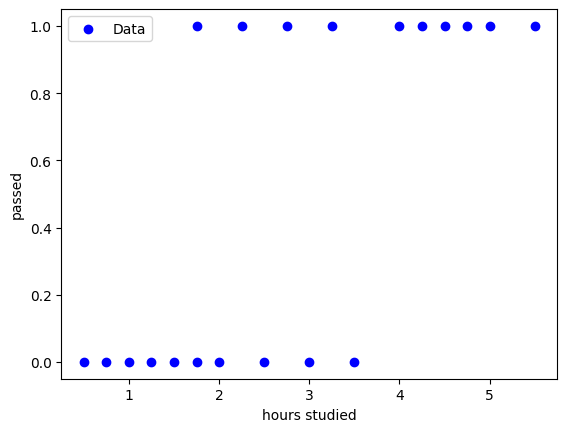

In [296]:
plot_data(data["hours_studied"], data["passed"], x_label="hours studied", y_label="passed")

In [297]:
X = data[["hours_studied"]]
y = data["passed"]

### Gradient Descent

First, we need to derive the loss function Binary Cross-Entropy to compute the gradients for Gradient Descent.

Be
$$
L_{w,b} = -\frac{1}{n} \sum_{i=1}^n [y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]
$$

our BCE or log-loss function.

As 
$$
\hat{y} = \sigma({\mathbf{X}w+b}) = \frac{1}{1 + e^{-(\mathbf{X}w+b)}}
$$

we get over all samples/ datapoints
$$
L_{w,b} = -\frac{1}{n} \sum_{i=1}^n [y_i\log(\frac{1}{1 + e^{-(\mathbf{x}_i^\mathsf{T}w+b)}}) + (1-y_i)\log(1-\frac{1}{1 + e^{-(\mathbf{x}_i^\mathsf{T}w+b)}})] 
$$

For readability, we will stick with
$$
L_{w,b} = -\frac{1}{n} \sum_{i=1}^n [y_i\log(\sigma(t_i)) + (1-y_i)\log(1-\sigma(t_i))]
$$
where $t$ = $Xw+b$ and hence $t_i = \mathbf{x}_i^\mathsf{T}\mathbf{w}+b$ where $\mathbf{x}_i^\mathsf{T} = \begin{bmatrix} x_{i,1} & \dots & x_{i,m} \end{bmatrix}$ is the transposed feature vector for one sample $i$ and $\mathbf{w} = \begin{bmatrix} w_1 \\ \dots \\ w_m \end{bmatrix}$ the current weight vector. Its result will be a single scalar.

Lets further simply:
$$
L_{w,b} = -\frac{1}{n} \sum_{i=1}^n[ y_i\log(\sigma(t_i)) + (1-y_i)\log(1-\sigma(t_i))] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\log(\sigma(t_i)) + (1-y_i)\log(1 - \frac{1}{1+e^{-t_i}})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\log(\sigma(t_i)) + (1-y_i)\log(\frac{1+e^{-t_i}}{1+e^{-t_i}} - \frac{1}{1+e^{-t_i}})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\log(\sigma(t_i)) + (1-y_i)\log(\frac{e^{-t_i}}{1+e^{-t_i}})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\log(\sigma(t_i)) + (1-y_i)\log(\frac{e^{-t_i}}{1+e^{-t_i}})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\log(\sigma(t_i)) + (1-y_i)\log(\frac{e^{-t_i}}{1+e^{-t_i}} \times \frac{e^{t_i}}{e^{t_i}})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\log(\sigma(t_i)) + (1-y_i)\log(\frac{e^{-t_i}e^{t_i}}{(1+e^{-t_i})e^{t_i}})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\log(\sigma(t_i)) + (1-y_i)\log(\frac{1}{1 + e^{t_i}})] \\
$$

as $a^xa^{-x} = a^{x + (-x)} = a^{x-x} = a^0 = 1$

Moreover, rewriting $\sigma(t_i)$ yields
$$
L_{w,b} = -\frac{1}{n} \sum_{i=1}^n [y_i\log(\sigma(t_i)) + (1-y_i)\log(\frac{1}{1 + e^{t_i}})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\log(\frac{1}{1+e^{-t_i}}) + (1-y_i)\log(\frac{1}{1 + e^{t_i}})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\log(\frac{e^{t_i}}{(1+e^{-t_i})e^{t_i}}) + (1-y_i)\log(\frac{1}{1 + e^{t_i}})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\log(\frac{e^{t_i}}{1+ e^{t_i}}) + (1-y_i)\log(\frac{1}{1 + e^{t_i}})] \\
$$

Also, using the reciprocal rule of logarithms $\log(\frac{1}{x}) = -\log(x)$ and the quatient rule $\log(\frac{y}{x}) = \log(y) - \log(x)$, we get
$$
L_{w,b} = -\frac{1}{n} \sum_{i=1}^n [y_i\log(\frac{e^{t_i}}{1+ e^{t_i}}) + (1-y_i)\log(\frac{1}{1 + e^{t_i}})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i(\log(e^{t_i})-\log(1+ e^{t_i})) + (1-y_i)(-\log(1 + e^{t_i}))] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i(t_i -\log(1+ e^{t_i})) + (1-y_i)(-\log(1 + e^{t_i}))] \\
$$

assuming $\log = \ln$.

Multiypling everything
$$
L_{w,b} = -\frac{1}{n} \sum_{i=1}^n [y_i(t_i -\log(1+ e^{t_i})) + (1-y_i)(-\log(1 + e^{t_i}))] \\
= -\frac{1}{n} \sum_{i=1}^n [y_it_i - y_i\log(1+ e^{t_i}) + (-\log(1+e^{t_i}) + y_i\log(1+e^{t_i}))] \\
= -\frac{1}{n} \sum_{i=1}^n [y_it_i - y_i\log(1+ e^{t_i}) -\log(1+e^{t_i}) + y_i\log(1+e^{t_i})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_it_i -\log(1+e^{t_i})] \\
$$

Hence we will derive $\nabla L_w$ and $\nabla L_b$ by
$$
\frac{\partial L}{\partial w} = \frac{\partial}{\partial w} [-\frac{1}{n} \sum_{i=1}^n [y_it_i -\log(1+e^{t_i})]] \\
= -\frac{1}{n} \sum_{i=1}^n [\frac{\partial}{\partial w} y_it_i - \frac{\partial}{\partial w} \log(1+e^{t_i})] \\
= -\frac{1}{n} \sum_{i=1}^n [\frac{\partial}{\partial w} y_i(\mathbf{x}_i^\mathsf{T}\mathbf{w}+b) - \frac{\partial}{\partial w} \log(1+e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b})] \\
$$
Applying the chain rule of calculus solving $\frac{d}{dx} ln(f(x)) = \frac{1}{f(x)} \times \frac{d}{dx}f(x)$
$$
= -\frac{1}{n} \sum_{i=1}^n [\frac{\partial}{\partial w} (y_i\mathbf{x}_i^\mathsf{T}\mathbf{w} +y_ib) - \frac{1}{1+e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}}(\frac{\partial}{\partial w}[1 + e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}])] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\mathbf{x}_i - \frac{1}{1+e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}}(\frac{\partial}{\partial w}1 + \frac{\partial}{\partial w}e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\mathbf{x}_i - \frac{1}{1+e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}}(\frac{\partial}{\partial w}[\mathbf{x}_i^\mathsf{T}\mathbf{w}+b] e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\mathbf{x}_i - \frac{1}{1+e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}}\mathbf{x}_i e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\mathbf{x}_i - \frac{e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}}{1+e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}}\mathbf{x}_i] \\
$$
We set $\frac{e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}}{1 + e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}} = \frac{e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}}{1 + e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}} \times \frac{e^{-(\mathbf{x}_i^\mathsf{T}\mathbf{w}+b)}}{e^{-(\mathbf{x}_i^\mathsf{T}\mathbf{w}+b)}} = \frac{1}{1+e^{-(\mathbf{x}_i^\mathsf{T}\mathbf{w}+b)}}$
$$
= -\frac{1}{n} \sum_{i=1}^n [y_i\mathbf{x}_i - \frac{1}{1+e^{-(\mathbf{x}_i^\mathsf{T}\mathbf{w}+b)}}\mathbf{x}_i)] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i\mathbf{x}_i - \sigma(t_i)\mathbf{x}_i)] \\
= -\frac{1}{n} \sum_{i=1}^n \mathbf{x}_i(y_i - \sigma(t_i)) \\
= \frac{1}{n} \sum_{i=1}^n \mathbf{x}_i(-y_i + \sigma(t_i)) \\
= \frac{1}{n} \sum_{i=1}^n \mathbf{x}_i(\sigma(t_i) - y_i) \\
$$

which is ultimately
$$
\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^n \mathbf{x}_i(\hat{y}_i - y_i) \\
$$


Let's continue with $\nabla L_b$
$$
\frac{\partial L}{\partial b} = \frac{\partial}{\partial b} [-\frac{1}{n} \sum_{i=1}^n [y_it_i -\log(1+e^{t_i})]] \\
= -\frac{1}{n} \sum_{i=1}^n [\frac{\partial}{\partial b} y_it_i - \frac{\partial}{\partial b} log(1+e^{t_i})] \\
= -\frac{1}{n} \sum_{i=1}^n [\frac{\partial}{\partial b} y_i(\mathbf{x}_i^\mathsf{T}\mathbf{w}+b) - \frac{1}{1 + e^{t_i}} \frac{\partial}{\partial b} [1+e^{t_i}]] \\
= -\frac{1}{n} \sum_{i=1}^n [\frac{\partial}{\partial b} (y_i\mathbf{x}_i^\mathsf{T}\mathbf{w} + y_ib) - \frac{1}{1 + e^{t_i}}(\frac{\partial}{\partial b} 1 + \frac{\partial}{\partial b} e^{t_i})] \\
= -\frac{1}{n} \sum_{i=1}^n [\frac{\partial}{\partial b} y_i\mathbf{x}_i^\mathsf{T}\mathbf{w} + \frac{\partial}{\partial b} y_ib - \frac{1}{1 + e^{t_i}} (\frac{\partial}{\partial b} e^{\mathbf{x}_i^\mathsf{T}\mathbf{w} + b})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i - \frac{1}{1 + e^{t_i}} (\frac{\partial}{\partial b} [\mathbf{x}_i^\mathsf{T}\mathbf{w}+b] e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b})] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i - \frac{1}{1 + e^{t_i}} e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i - \frac{e^{\mathbf{x}_i^\mathsf{T}\mathbf{w}+b}}{1 + e^{t_i}}] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i - \frac{1}{1 + e^{-(\mathbf{x}_i^\mathsf{T}\mathbf{w}+b)}}] \\
= -\frac{1}{n} \sum_{i=1}^n [y_i - \sigma(t_i)] \\
= \frac{1}{n} \sum_{i=1}^n [\sigma(t_i) - y_i]
$$

which is ultimately
$$
\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^n [\hat{y}_i - y_i] \\
$$


In [298]:
%run src/logistic_regression.py

### Implementation

`src/logistic_regression.py` holds the implementation of Logistic Regression with Gradient Descent using pure NumPy.

The implementation was built according to the derived Binary Cross-Entropy loss function and uses the sigmoid function with the linear relationships to make prediction. The threshold is set to 0.5.

In the following we will create an instance of the written LogisticRegressionGD to perform Logistic Regression and predict if one person passed a test based on the amount of hours studied.

In [299]:
logistic_regression_model = LogisticRegressionGD()

logistic_regression_model.fit(X, y, learning_rate=0.01, max_iter=500_000, tol=1e-6)

### Plot of fitted logistic function

Below we can plot the the logistic function using our sigmoid function and linear interpretation of the data $Xw+b$. For $w$ and $b$, we'll use the learning and optimized parameters.

Here, datapoints color red were classified as $0$ (not passed) whereas green corresponds to class $1$ (passed).

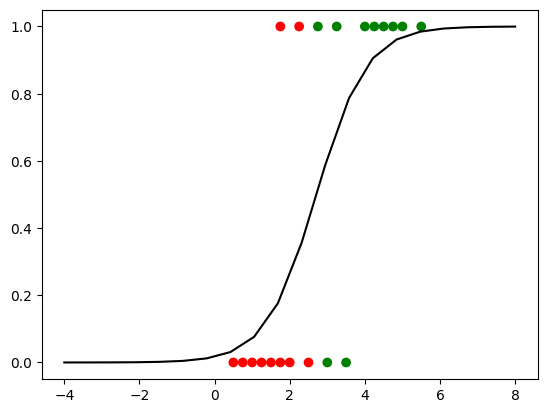

In [300]:
color = ["red", "green"]

y_pred = logistic_regression_model.predict(X)
sample_colors = [color[pred] for pred in y_pred]

plt.scatter(X, y, c=sample_colors)

w, b = logistic_regression_model.coefs_, logistic_regression_model.intercept_
x_values = np.linspace(-4, 8, 20)
y_values = logistic_regression_model.sigmoid(x_values * w + b)

plt.plot(x_values, y_values, color="black")

plt.show()

### Comparison to assess model performance and validate algorithm

Now, we will compare the resulting parameters $w$ and $b$ from our implementation to scikit-learn's Logistic Regression.

Scikit-Learn does not use raw Gradient Descent and applies penalties. The following configuration tries to make it as comparable to our own implementation as possible by disabling the penalty and using the Stochastic Average Gradient.

SAG is another form of Gradient Descent, calculating the gradient one sample at a time, remembering old values and using their average.

More variants of Gradient Descent can be explored in `3_variants_of_gd`.

We will compare our own implementation, scikit-learn's Logistic Regression, as well as the figures noted on the Logistic Regression Wikipedia page for the data used.

We will compare them using 2 metrics in particular:

**1)** Decision Boundary $\mu$

We can calculate the decision boundary for Logistic Regression, essentially the point or hyperplane in feature space where the predicted probability is $P(y=1 | \mathbf{x}) = 0.5$ (or for $m=1$ features, we'd like to find the $x$-coordinate where $y = 0.5$)

Mathematically, our model is designed to estimate

$$
P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{x}^T\mathbf{w}+b)
$$

meaning the probability that our binary class is $1$ (the "positive" class) given the feature value vector $\mathbf{x}$.

By deciding the threshold to be $0.5$, e.g. we need a probability of 50\% or above the get class 1, we get

$$
P(y=1 \mid \mathbf{x}) = 0.5
\Leftrightarrow
\sigma(\mathbf{x}^T\mathbf{w}+b) = 0.5
$$

Consequently,

$$
\sigma(\mathbf{x}^T\mathbf{w}+b) = 0.5
\Leftrightarrow
\frac{1}{1+e^{-(\mathbf{x}^T\mathbf{w}+b)}} = 0.5
\Leftrightarrow
1 = 0.5 + 0.5e^{-(\mathbf{x}^T\mathbf{w}+b)}
\Leftrightarrow
1 = e^{-(\mathbf{x}^T\mathbf{w}+b)}
$$

Finally,

$$
\ln(1) = \ln(e^{-(\mathbf{x}^T\mathbf{w}+b)})
\Leftrightarrow
0 = \mathbf{x}^T\mathbf{w}+b
$$

Hence, we will solve for $\mathbf{x}$ as we want the $x$ coordinates per feature where $y=0.5$.

For one feature ($x,w \in \mathbb{R}$):

$$
0 = xw+b
\Leftrightarrow
\frac{-b}{w} = x
$$

the decision boundary is a single scalar. We could now say that every $x_i$ with $x_i <$ decision boundary will be classified as class 0 and as class 1 if $x_i >$ decision boundary when $w \geq 0$ and the other way around for $w < 0$.

Example if our decision boundary is $\mu = 3$, then every student who studied less than $3$ hours will be classified as class $0$ (failed), whereas every student with $x_i \geq 3$ will be classified as class $1$ (passed).

However this concept only applies to data with $1$ feature. For $m > 1$ features, the decision boundary is defined by $\mathbf{Xw}+b$ and dependent on every datapoint in the data matrix $\mathbf{X}$. Instead of a cutoff scalar, we get a $m$-dimensional hyperplane defined by $\mathbf{x}^T\mathbf{w}+b = 0 = 0$.

So instead of a direct cutoff-scalar, we can calculate the probability for each sample/ row in our dataset and whether it lies "below" or "above" that hyperplane:

$$
\begin{bmatrix} \hat{y}_1 \\ \dots \\ \hat{y}_n \end{bmatrix} =
\begin{bmatrix}
\sigma(\mathbf{x}_1^T\mathbf{w}+b = 0) \\
\dots \\
\sigma(\mathbf{x}_n^T\mathbf{w}+b = 0)
\end{bmatrix}
$$

which is exactly what our prediction is doing.

So essentially, Logistic Regression finds the most optimal parameters $w_i$ and $b$ that define the best linear boundary between two classes.

To plot the line or hyperplane, we do the same as for our $m = 1$ case: we solve for one (arbitrary) parameter, e.g.

$$
0 = \mathbf{x}^T\mathbf{w}+b
\Leftrightarrow
0 = x_1w_1+\dots+x_iw_i+\dots+x_mw_m+b
$$

$$
\Leftrightarrow
x_iw_i = -b-\sum_{j\ne i}x_jw_j
$$

$$
\Leftrightarrow
x_i = -\frac{b+\sum_{j\ne i}x_jw_j}{w_i}
$$


### Decision Boundary plot for m=1

We can plot the decision boundary scalar for the single feature example. Hence we calculate

$$
\mu = \frac{-b}{w} = \frac{-(-4.08)}{1.5} = 2.71
$$

and plot the cutoff (decision boundary).

This explains the previous plot as we can now understand why some datapoints were classified as not passed ("red") and others as passed ("green): Every sample with $x < 2.71$ where $x =$ hours studied is classified as not passed vice-versa.

It becomes obvious that while these are the optimal values for Logistic Regression for this data, the approximated parameters are not without flaws: 4 datapoints were classified incorrectly.

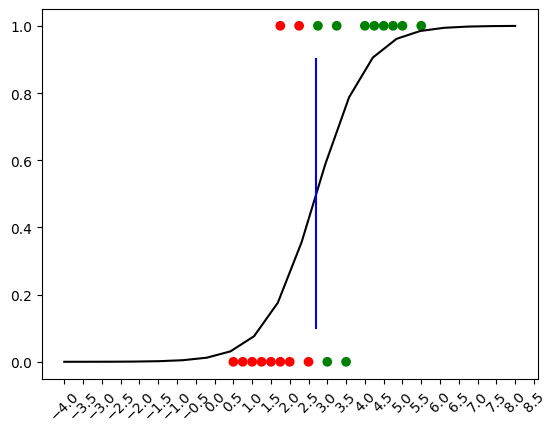

In [301]:
color = ["red", "green"]

y_pred = logistic_regression_model.predict(X)
sample_colors = [color[pred] for pred in y_pred]

plt.scatter(X, y, c=sample_colors)

w, b = logistic_regression_model.coefs_, logistic_regression_model.intercept_
x_values = np.linspace(-4, 8, 20)
y_values = logistic_regression_model.sigmoid(x_values * w + b)

plt.plot(x_values, y_values, color="black")

db = logistic_regression_model.decision_boundary
y_cont_values = np.linspace(0.1, 0.9, 2)
plt.plot([db]*2, y_cont_values, color="blue")

plt.xticks(np.arange(-4, 9, step=0.5), rotation=45)
plt.show()

### Comparison to scikit-learn's Logistic Regression and Wikipedia

To validate our implementation, we compared the learned feature weight, intercept, decision boundary and inverse slope against scikit-learn's LogisticRegression (configured with penalty=None and solver "sag") and the published Wikipedia benchmark values.

Our custom model yields identical parameter values across all metrics, confirming the correct convergence of our optimization routine.

In [302]:
sklearn_lr = LogisticRegression(
    penalty=None,
    tol=1e-6,
    max_iter=500_000,
    solver="sag"
)
sklearn_lr.fit(X, y)

LogisticRegression(max_iter=500000, penalty=None, solver='sag', tol=1e-06)

In [303]:
evaluation_df = pd.DataFrame(
    {
        "metric": ["Coefficient", "Intercept", "Decision Boundary", "Inverse Slope"],
        "implementation": [logistic_regression_model.coefs_[0], logistic_regression_model.intercept_, logistic_regression_model.decision_boundary[0], (1 / logistic_regression_model.coefs_)[0]],
        "sklearn": [sklearn_lr.coef_[0][0], sklearn_lr.intercept_[0], -(sklearn_lr.intercept_ / sklearn_lr.coef_)[0][0], (1/sklearn_lr.coef_)[0][0]],
        "wikipedia": [1.5, -4.1, 2.7, 0.67]
    }
)

evaluation_df

,metric,implementation,sklearn,wikipedia
0,Coefficient,1.504622,1.504603,1.50
1,Intercept,-4.077644,-4.077590,-4.10
2,Decision Boundary,2.710079,2.710076,2.70
3,Inverse Slope,0.664619,0.664627,0.67


### Adding one dimension to the feature space with $m=2$

Adding another dimension, the attendence rate, to our data and increasing our feature dimension $m$ from $1$ to $2$, we get get a line defined by $\mathbf{x^Tw+b}$ instead of a single scalar for our decision boundary.

Setting $\mathbf{x^Tw+b} = 0$ and solving for either $x_1$ or $x_2$ yield the corresponding y values for our line.

In [304]:
data["attendance_rate"] = [0.40, 0.45, 0.50, 0.55, 0.60, 0.52, 0.88, 0.62, 0.85, 0.65, 0.82, 0.70, 0.90, 0.72, 0.85, 0.92, 0.88, 0.95, 0.91, 0.98]
X = data[["hours_studied", "attendance_rate"]]
y = data["passed"]

logistic_regression_model_2 = LogisticRegressionGD()
logistic_regression_model_2.fit(X, y, learning_rate=0.01, max_iter=500_000, tol=1e-6)
w, b = logistic_regression_model_2.decision_boundary
w, b

(array([-0.2368073 , 28.95505408]), np.float64(-21.31080250519366))

Instead of plotting the predicted classes for our new data problem, we plot the true (real) classes, where green is passed and red is not passed.

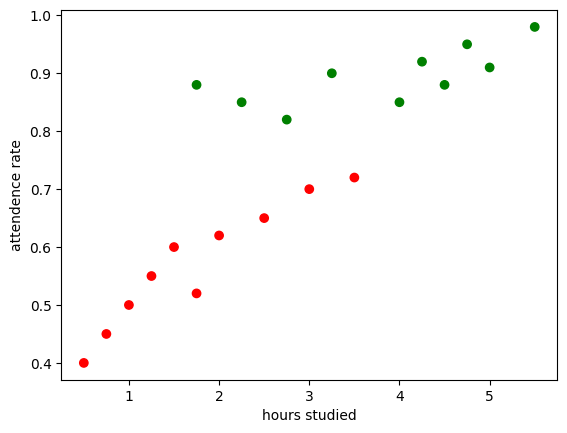

In [305]:
color = ["red", "green"]
true_colors = [color[idx] for idx in y]
plt.scatter(X["hours_studied"], X["attendance_rate"], c=true_colors)
plt.xlabel("hours studied")
plt.ylabel("attendence rate")

plt.show()

Optimizing for $\mathbf{w}$ and $b$ and solving for $x_1$ yields the decision boundary line.

We first choose the min and max values from $x_0$ as the start and end points for our line for which we will calculate the corresponding $y$ values by

$$
x_1 = \frac{-(b+x_0w_0)}{w_1}
$$

The resulting line perfectly determines the decision boundary for classes "passed" and "not passed".

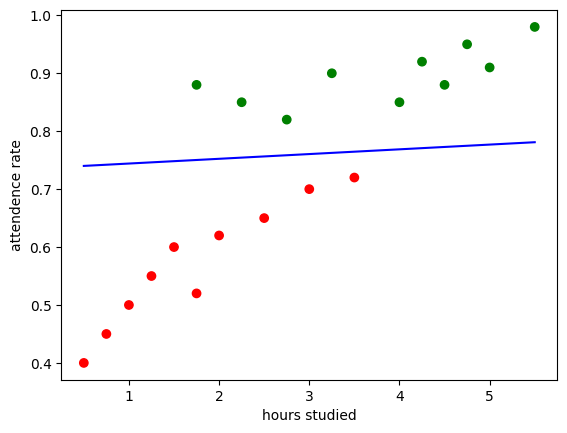

In [306]:
color = ["red", "green"]
true_colors = [color[idx] for idx in y]
plt.scatter(X["hours_studied"], X["attendance_rate"], c=true_colors)
plt.xlabel("hours studied")
plt.ylabel("attendence rate")

x_0 = np.array([X["hours_studied"].min(), X["hours_studied"].max()])
x_1 = -(b + x_0*w[0]) / w[1]

plt.plot(x_0, x_1, color="blue")


plt.show()

### Real Data: Titanic Survival

For a real dataset, we'll use the classic Titanic survival dataset for predict the binary classification of whether a passenger survived based on some stats.

The dataset can be examinded below.

In [307]:
data = pd.read_csv("data/titanic_dataset.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We'll quickly clean the dataset and only use numerical features, hence our feature space $m = 4$ consists of the class of the passenger, their gender, age and ticket price paid. We will predict whether a passenger survived as target.

In [308]:
data["Sex"] = data["Sex"].apply(lambda x: 1 if x == "male" else 0)
data = data.drop(columns=["PassengerId", "Name", "SibSp", "Parch", "Ticket", "Cabin", "Embarked"])
data = data[~data["Age"].isna()]

data.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,1,22.0,7.2500
1,1,1,0,38.0,71.2833
2,1,3,0,26.0,7.9250
3,1,1,0,35.0,53.1000
4,0,3,1,35.0,8.0500


In [309]:
X = data.drop(columns=["Survived"])
y = data["Survived"]

In [346]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=25)

In [348]:
model = LogisticRegressionGD()
model.fit(X_train, y_train, learning_rate=0.001, max_iter=500_000, tol=1e-10)

In [349]:
y_pred = model.predict(X_test)

In [347]:
sklearn_lr = LogisticRegression(
    penalty=None,
    tol=1e-10,
    max_iter=500_000,
    solver="sag"
)
sklearn_lr.fit(X_train, y_train)
y_pred_sklearn = sklearn_lr.predict(X_test)

In [314]:
def accuracy(y_true, y_pred) -> float:
    return 1 - np.sum(np.abs(y_true - y_pred)) / len(y_true)

def recall(y_true, y_pred) -> float:
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def precision(y_true, y_pred) -> float:
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

### Performance metric comparison

Both implementations achieved an accuracy of 77.8%. This means that they correctly identified the classes 77.8% of the samples, respectively.

Furthermore, the NumPy implementation got a recall of 73% whereas sklearn achieved a recall of 75%. This means that, out of all passengers who actually survived, they correctly identified 73% and 75% of the cases, respectively.

Lastly, our implementation achieved a precision of 73%, while scikit-learn achieved a precision of 72%. This means that, when predicting that a passenger survived, the predictions were correct 73% and 72% of the time, respectively.

These differences in performance metrics imply that the two implementations must have converged to different parameter values $w_i$ and $b$ for the same problem, while also using different variants of Gradient Descent, resulting in different predictions.


In [350]:
metric_comparison = pd.DataFrame(
    {
        "metric": ["accuracy", "recall", "precision"],
        "implementation": [accuracy(y_test, y_pred), recall(y_test, y_pred), precision(y_test, y_pred)],
        "sklearn": [accuracy(y_test, y_pred_sklearn), recall(y_test, y_pred_sklearn), precision(y_test, y_pred_sklearn)]
    }
).set_index("metric")
metric_comparison

,implementation,sklearn
metric,,
accuracy,0.777778,0.777778
recall,0.727273,0.750000
precision,0.727273,0.717391


### Parameter comparison

What we predicted previously proves to be true: both algorithms converged to a different set of parameters.

While not different by an order of magnitude, it proves to be that the diffrent variants of GD converged to different parameters given the max. number of iterations.

In [352]:
parameter_comparison = pd.DataFrame(
    {
        "parameters": [f"w_{i}" for i in range(len(model.coefs_))] + ["b"],
        "implementation": np.append(model.coefs_, model.intercept_),
        "sklearn": np.append(sklearn_lr.coef_[0], sklearn_lr.intercept_),
    }
).set_index("parameters")
parameter_comparison

,implementation,sklearn
parameters,,
w_0,-1.114091,-1.296178
w_1,-2.474869,-2.585948
w_2,-0.027734,-0.033990
w_3,-0.000592,-0.002429
b,4.416483,5.142588


### Loss 

Lastly, we'll compare the model's train loss to quantify their performance.

Hence we will use the binary cross-entropy (or log-loss) formula of

$$
L_{w,b} = -\frac{1}{n} \sum_{i=1}^n [y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]
$$

and insert $y_{train}$ as well as $X_{train}$ to obtain the training loss with

$$
\hat{y_i} = \sigma(\mathbf{x_i^Tw}+b) = \frac{1}{1+e^{-(\mathbf{x_i^Tw}+b)}} 
$$

Here, a result approaching $0.0$ would indicate extremely confident and correct predictions. Theoretically, a loss of exactly $0$ is achieved when the model assigns probability $1$ to the correct class for every sample.

We would achieve a result of 0.693 for random guessing every answer, so we'll use that as our upper boundary and baseline:

As $E[y] = 0.5$ and $E[\hat{y}] = 0.5$ for 2 classes 0 and 1 would indicate random guessing, the formula yields
$$
-[0.5 \times \log(0.5) + (1-0.5)\log(1-0.5)] = -(0.5 \times \log(0.5) + 0.5 \times \log(0.5)) = -log(0.5) = 0.693
$$

In [353]:
model_loss = model.loss_
print(f"Log-Loss of own implementation: {model_loss}")

Log-Loss of own implementation: 0.45392577487971597


In [354]:
from sklearn.metrics import log_loss

sklearn_pred_proba = sklearn_lr.predict_proba(X_train)[:, 1]
sklearn_lr_log_loss = log_loss(y_train, sklearn_pred_proba)
print(f"Log-loss of sklearn's LogisticRegression: {sklearn_lr_log_loss}")

Log-loss of sklearn's LogisticRegression: 0.45288010034196813
